# Bureau Balance Exploratory Analysis

This notebook explores the monthly bureau-balance dataset. It contains the monthly status history of credit accounts reported by other financial institutions.

The analysis checks the structure of the data, monthly status codes, length and continuity of credit history, connections with the bureau dataset and relationships between past delinquency and default.

## Import libraries


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 100)
sns.set_style("whitegrid")

BLUE = "#2E6DB4"
ORANGE = "#E67E22"

print("Libraries imported successfully.")


Libraries imported successfully.


## Set file paths


In [5]:
balance_path = "data/raw/bureau_balance.csv"
bureau_path = "data/raw/bureau.csv"
application_path = "data/raw/application_train.csv"


## Load the data


In [7]:
balance_types = {
    "SK_ID_BUREAU": "int32",
    "MONTHS_BALANCE": "int16",
    "STATUS": "category",
}

bureau_balance = pd.read_csv(balance_path, dtype=balance_types)
bureau_links = pd.read_csv(bureau_path, usecols=["SK_ID_BUREAU", "SK_ID_CURR"])
application_target = pd.read_csv(application_path, usecols=["SK_ID_CURR", "TARGET"])

print("Bureau-balance rows:", bureau_balance.shape[0])
print("Bureau-balance columns:", bureau_balance.shape[1])
print("Memory used by bureau_balance:", round(bureau_balance.memory_usage(deep=True).sum() / 1024**2, 2), "MB")
bureau_balance.head()


Bureau-balance rows: 27299925
Bureau-balance columns: 3
Memory used by bureau_balance: 182.25 MB


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


SK_ID_BUREAU identifies the bureau credit account, and MONTHS_BALANCE shows how many months before the current application the status was recorded. A value of 0 is the most recent month, and negative values are earlier months.


## Structure, missingness, and key checks


In [10]:
credit_month_key = ["SK_ID_BUREAU", "MONTHS_BALANCE"]

print("Missing SK_ID_BUREAU:", bureau_balance["SK_ID_BUREAU"].isna().sum())
print("Missing MONTHS_BALANCE:", bureau_balance["MONTHS_BALANCE"].isna().sum())
print("Missing STATUS:", bureau_balance["STATUS"].isna().sum())
print("Duplicate credit-month keys:", bureau_balance.duplicated(credit_month_key).sum())
print("Unique bureau credits with balance history:", bureau_balance["SK_ID_BUREAU"].nunique())
print("Minimum month:", bureau_balance["MONTHS_BALANCE"].min())
print("Maximum month:", bureau_balance["MONTHS_BALANCE"].max())


Missing SK_ID_BUREAU: 0
Missing MONTHS_BALANCE: 0
Missing STATUS: 0
Duplicate credit-month keys: 0
Unique bureau credits with balance history: 817395
Minimum month: -96
Maximum month: 0


No missing identifiers, missing statuses, or duplicate account-month records were found. The monthly values go from -96 to 0, so there is no future month value.


## Status-code distribution


The `STATUS` column describes the condition of a bureau credit account during each month:

- `0`: no payment delay
- `1`: payment was 1–30 days late
- `2`: payment was 31–60 days late
- `3`: payment was 61–90 days late
- `4`: payment was 91–120 days late
- `5`: payment was more than 120 days late or written off
- `C`: the credit was closed
- `X`: the monthly status was unknown

,count,percent
STATUS,,
0,7499507,27.471
1,242347,0.888
2,23419,0.086
3,8924,0.033
4,5847,0.021
5,62406,0.229
C,13646993,49.989
X,5810482,21.284


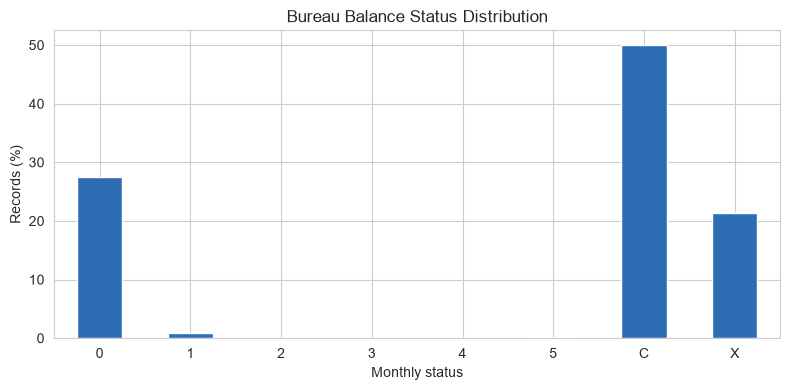

In [14]:
status_order = ["0", "1", "2", "3", "4", "5", "C", "X"]
status_count = bureau_balance["STATUS"].value_counts().reindex(status_order, fill_value=0)
status_table = pd.DataFrame({
    "count": status_count,
    "percent": status_count / len(bureau_balance) * 100,
})
display(status_table.round(3))

plt.figure(figsize=(8, 4))
status_table["percent"].plot(kind="bar", color=BLUE)
plt.title("Bureau Balance Status Distribution")
plt.xlabel("Monthly status")
plt.ylabel("Records (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
valid_statuses = {"0", "1", "2", "3", "4", "5", "C", "X"}

status_values = bureau_balance["STATUS"].astype("string")

validity_checks = pd.DataFrame({
    "check": [
        "Missing status",
        "Invalid status code",
        "Future balance month",
        "Extremely old balance month"
    ],
    "rows_affected": [
        status_values.isna().sum(),
        (~status_values.isin(valid_statuses) & status_values.notna()).sum(),
        (bureau_balance["MONTHS_BALANCE"] > 0).sum(),
        (bureau_balance["MONTHS_BALANCE"] < -1200).sum()
    ]
})

validity_checks

,check,rows_affected
0,Missing status,0
1,Invalid status code,0
2,Future balance month,0
3,Extremely old balance month,0


Almost half of the monthly records have status C, meaning the credit account was closed. A large share also have status X, meaning the monthly condition was unknown. The delinquency statuses from 1 to 5 are much less common. All the status and month values look valid, so nothing needs to be fixed here.


## Monthly history per bureau credit


In [18]:
history_summary = bureau_balance.groupby("SK_ID_BUREAU", observed=True)["MONTHS_BALANCE"].agg(["count", "min", "max"])
history_summary.columns = ["MONTH_COUNT", "OLDEST_MONTH", "MOST_RECENT_MONTH"]
history_summary["EXPECTED_MONTH_COUNT"] = history_summary["MOST_RECENT_MONTH"] - history_summary["OLDEST_MONTH"] + 1
history_summary["MISSING_MONTH_COUNT"] = history_summary["EXPECTED_MONTH_COUNT"] - history_summary["MONTH_COUNT"]

history_summary[["MONTH_COUNT", "OLDEST_MONTH", "MOST_RECENT_MONTH", "MISSING_MONTH_COUNT"]].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)


,MONTH_COUNT,OLDEST_MONTH,MOST_RECENT_MONTH,MISSING_MONTH_COUNT
count,817395.000000,817395.000000,817395.000000,817395.0
mean,33.398693,-39.432847,-7.034154,0.0
std,25.794666,28.132570,17.026851,0.0
min,1.000000,-96.000000,-96.000000,0.0
25%,13.000000,-58.000000,-1.000000,0.0
50%,26.000000,-34.000000,0.000000,0.0
75%,48.000000,-16.000000,0.000000,0.0
90%,77.000000,-7.000000,0.000000,0.0
95%,90.000000,-4.000000,0.000000,0.0
99%,97.000000,-1.000000,0.000000,0.0


Credits with at least one gap in monthly history: 0
Percentage with gaps: 0.0 %


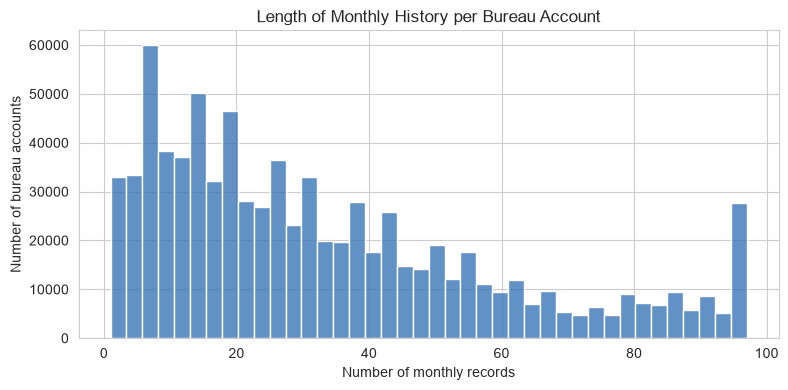

In [19]:
credits_with_month_gaps = (history_summary["MISSING_MONTH_COUNT"] > 0).sum()
print("Credits with at least one gap in monthly history:", credits_with_month_gaps)
print("Percentage with gaps:", round(credits_with_month_gaps / len(history_summary) * 100, 3), "%")

plt.figure(figsize=(8, 4))
sns.histplot(history_summary["MONTH_COUNT"], bins=40, color=BLUE)
plt.title("Length of Monthly History per Bureau Account")
plt.xlabel("Number of monthly records")
plt.ylabel("Number of bureau accounts")
plt.tight_layout()
plt.show()


A bureau account has a median of 26 months of recorded history. No gaps were found between the oldest and most recent month for any account, so the monthly records form a continuous sequence within each account.


## Connection with the bureau dataset


In [22]:
balance_bureau_ids = set(bureau_balance["SK_ID_BUREAU"].unique())
bureau_ids = set(bureau_links["SK_ID_BUREAU"].unique())

matched_bureau_ids = balance_bureau_ids.intersection(bureau_ids)
unmatched_balance_ids = balance_bureau_ids.difference(bureau_ids)
bureau_ids_without_balance = bureau_ids.difference(balance_bureau_ids)

print("Balance bureau IDs matched to bureau.csv:", len(matched_bureau_ids))
print("Balance bureau IDs not found in bureau.csv:", len(unmatched_balance_ids))
print("Bureau credits without balance history:", len(bureau_ids_without_balance))


Balance bureau IDs matched to bureau.csv: 774354
Balance bureau IDs not found in bureau.csv: 43041
Bureau credits without balance history: 942074


Most bureau-balance accounts can be matched to the main bureau dataset and connected to an applicant using SK_ID_CURR. The accounts that cannot be matched will be excluded from applicant-level analysis. A large number of bureau credits also do not have any monthly bureau-balance history at all.


## Monthly credit behaviour

Each bureau account can have many monthly records, so a few temporary account-level summaries are created here to describe things like credit history length, delinquent months, and unknown statuses. These are only for exploration, the complete bureau-balance features will be created later.


In [25]:
bureau_balance["IS_DELINQUENT"] = bureau_balance["STATUS"].isin(["1", "2", "3", "4", "5"]).astype("int8")
bureau_balance["IS_SEVERE_DELINQUENCY"] = bureau_balance["STATUS"].isin(["3", "4", "5"]).astype("int8")
bureau_balance["IS_CLOSED"] = (bureau_balance["STATUS"] == "C").astype("int8")
bureau_balance["IS_UNKNOWN"] = (bureau_balance["STATUS"] == "X").astype("int8")
bureau_balance["IS_RECENT_12_MONTHS"] = (bureau_balance["MONTHS_BALANCE"] >= -11).astype("int8")
bureau_balance["RECENT_DELINQUENCY"] = (
    (bureau_balance["IS_DELINQUENT"] == 1) & (bureau_balance["IS_RECENT_12_MONTHS"] == 1)
).astype("int8")

credit_behaviour = bureau_balance.groupby("SK_ID_BUREAU", observed=True).agg(
    BB_MONTH_COUNT=("MONTHS_BALANCE", "count"),
    BB_OLDEST_MONTH=("MONTHS_BALANCE", "min"),
    BB_MOST_RECENT_MONTH=("MONTHS_BALANCE", "max"),
    BB_DELINQUENT_MONTH_COUNT=("IS_DELINQUENT", "sum"),
    BB_DELINQUENT_MONTH_RATE=("IS_DELINQUENT", "mean"),
    BB_SEVERE_MONTH_COUNT=("IS_SEVERE_DELINQUENCY", "sum"),
    BB_UNKNOWN_MONTH_RATE=("IS_UNKNOWN", "mean"),
    BB_CLOSED_MONTH_RATE=("IS_CLOSED", "mean"),
    BB_RECENT_OBSERVED_MONTHS=("IS_RECENT_12_MONTHS", "sum"),
    BB_RECENT_DELINQUENT_COUNT=("RECENT_DELINQUENCY", "sum"),
).reset_index()

print("Credit-level rows:", len(credit_behaviour))
credit_behaviour.head()


Credit-level rows: 817395


,SK_ID_BUREAU,BB_MONTH_COUNT,BB_OLDEST_MONTH,BB_MOST_RECENT_MONTH,BB_DELINQUENT_MONTH_COUNT,BB_DELINQUENT_MONTH_RATE,BB_SEVERE_MONTH_COUNT,BB_UNKNOWN_MONTH_RATE,BB_CLOSED_MONTH_RATE,BB_RECENT_OBSERVED_MONTHS,BB_RECENT_DELINQUENT_COUNT
0,5001709,97,-96,0,0,0.0,0,0.113402,0.886598,12,0
1,5001710,83,-82,0,0,0.0,0,0.361446,0.578313,12,0
2,5001711,4,-3,0,0,0.0,0,0.250000,0.000000,4,0
3,5001712,19,-18,0,0,0.0,0,0.000000,0.473684,12,0
4,5001713,22,-21,0,0,0.0,0,1.000000,0.000000,12,0


The monthly records are now summarized into one row per bureau account. These temporary summaries make it possible to compare accounts that have different lengths of monthly history.


## Connect bureau accounts to applicants

The bureau-balance file only has SK_ID_BUREAU, not SK_ID_CURR. So the bureau dataset is used here to link each bureau account back to the applicant.


In [28]:
credit_with_applicant = credit_behaviour.merge(
    bureau_links,
    on="SK_ID_BUREAU",
    how="inner",
    validate="one_to_one",
)

print("Credit summaries matched to applicants:", len(credit_with_applicant))
print("Unmatched credit summaries excluded from applicant aggregation:", len(credit_behaviour) - len(credit_with_applicant))


Credit summaries matched to applicants: 774354
Unmatched credit summaries excluded from applicant aggregation: 43041


In [29]:
applicant_balance = credit_with_applicant.groupby("SK_ID_CURR").agg(
    BB_CREDIT_COUNT=("SK_ID_BUREAU", "count"),
    BB_TOTAL_MONTH_COUNT=("BB_MONTH_COUNT", "sum"),
    BB_AVG_DELINQUENT_RATE=("BB_DELINQUENT_MONTH_RATE", "mean"),
    BB_MAX_DELINQUENT_RATE=("BB_DELINQUENT_MONTH_RATE", "max"),
    BB_TOTAL_DELINQUENT_MONTHS=("BB_DELINQUENT_MONTH_COUNT", "sum"),
    BB_TOTAL_SEVERE_MONTHS=("BB_SEVERE_MONTH_COUNT", "sum"),
    BB_TOTAL_RECENT_OBSERVED=("BB_RECENT_OBSERVED_MONTHS", "sum"),
    BB_TOTAL_RECENT_DELINQUENT=("BB_RECENT_DELINQUENT_COUNT", "sum"),
    BB_AVG_UNKNOWN_RATE=("BB_UNKNOWN_MONTH_RATE", "mean"),
).reset_index()

applicant_balance["BB_OVERALL_DELINQUENT_RATE"] = (
    applicant_balance["BB_TOTAL_DELINQUENT_MONTHS"] / applicant_balance["BB_TOTAL_MONTH_COUNT"]
)
applicant_balance["BB_RECENT_DELINQUENT_RATE"] = np.where(
    applicant_balance["BB_TOTAL_RECENT_OBSERVED"] > 0,
    applicant_balance["BB_TOTAL_RECENT_DELINQUENT"] / applicant_balance["BB_TOTAL_RECENT_OBSERVED"],
    np.nan,
)

print("Applicants with bureau-balance features:", len(applicant_balance))
applicant_balance.head()


Applicants with bureau-balance features: 134542


,SK_ID_CURR,BB_CREDIT_COUNT,BB_TOTAL_MONTH_COUNT,BB_AVG_DELINQUENT_RATE,BB_MAX_DELINQUENT_RATE,BB_TOTAL_DELINQUENT_MONTHS,BB_TOTAL_SEVERE_MONTHS,BB_TOTAL_RECENT_OBSERVED,BB_TOTAL_RECENT_DELINQUENT,BB_AVG_UNKNOWN_RATE,BB_OVERALL_DELINQUENT_RATE,BB_RECENT_DELINQUENT_RATE
0,100001,7,172,0.007519,0.052632,1,0,73,1,0.214590,0.005814,0.013699
1,100002,8,110,0.255682,0.500000,27,0,16,0,0.161932,0.245455,0.000000
2,100005,3,21,0.000000,0.000000,0,0,20,0,0.136752,0.000000,0.000000
3,100010,2,72,0.000000,0.000000,0,0,10,0,0.000000,0.000000,0.000000
4,100013,4,230,0.027701,0.045455,7,0,48,0,0.254545,0.030435,0.000000


The account-level summaries are now combined into one row per applicant. These values describe things like the applicant's number of bureau accounts, total monthly history, and delinquency, but they are still temporary EDA summaries, not the final features.


## Relationship with default

Comparing the bureau-balance summaries with the known default outcome for each applicant.


In [32]:
applicant_balance_target = application_target.merge(applicant_balance, on="SK_ID_CURR", how="left")
applicant_balance_target["HAS_BUREAU_BALANCE"] = applicant_balance_target["BB_CREDIT_COUNT"].notna()

coverage_default_summary = applicant_balance_target.groupby("HAS_BUREAU_BALANCE")["TARGET"].agg(["count", "mean"])
coverage_default_summary["default_rate_percent"] = coverage_default_summary["mean"] * 100
coverage_default_summary.drop(columns="mean").round(2)


,count,default_rate_percent
HAS_BUREAU_BALANCE,,
False,215280,8.04
True,92231,8.14


In [33]:
feature_columns = [column for column in applicant_balance.columns if column != "SK_ID_CURR"]
feature_correlations = applicant_balance_target[feature_columns + ["TARGET"]].corr()["TARGET"].drop("TARGET")
feature_correlations.sort_values().to_frame("correlation_with_target").round(4)


,correlation_with_target
BB_TOTAL_MONTH_COUNT,-0.0440
BB_TOTAL_RECENT_OBSERVED,-0.0093
BB_AVG_UNKNOWN_RATE,0.0004
BB_CREDIT_COUNT,0.0061
BB_TOTAL_SEVERE_MONTHS,0.0118
BB_TOTAL_DELINQUENT_MONTHS,0.0248
BB_TOTAL_RECENT_DELINQUENT,0.0400
BB_RECENT_DELINQUENT_RATE,0.0457
BB_MAX_DELINQUENT_RATE,0.0575
BB_OVERALL_DELINQUENT_RATE,0.0589


In [34]:
delinquent_count = applicant_balance_target["BB_TOTAL_DELINQUENT_MONTHS"]
applicant_balance_target["DELINQUENCY_GROUP"] = np.select(
    [delinquent_count.isna(), delinquent_count > 0],
    ["No bureau-balance history", "Has delinquent months"],
    default="No delinquent months",
)

delinquency_default_summary = applicant_balance_target.groupby("DELINQUENCY_GROUP")["TARGET"].agg(["count", "mean"])
delinquency_default_summary["default_rate_percent"] = delinquency_default_summary["mean"] * 100
delinquency_default_summary.drop(columns="mean").round(2)


,count,default_rate_percent
DELINQUENCY_GROUP,,
Has delinquent months,31052,9.96
No bureau-balance history,215280,8.04
No delinquent months,61179,7.22


Having bureau-balance history at all does not seem to matter much for default, the default rate is almost the same either way. But applicants with at least one delinquent month do default more often than applicants with bureau-balance history and no delinquent months. The average and overall delinquency rates have the strongest correlations with default among these summaries, though they are still fairly small.


## Main findings

The bureau-balance dataset contains monthly status records for bureau credit accounts. The bureau dataset is needed to connect these accounts to individual applicants.

The main findings are:

- The dataset contains 27,299,925 monthly records for 817,395 bureau accounts.
- No missing identifiers, missing statuses, or duplicate account-month records were found.
- Monthly history goes back up to 96 months, with no future month values or gaps.
- About half of the monthly records have a closed-account status, and unknown status is also common.
- Delinquent statuses are less common than closed, unknown, and non-delinquent statuses.
- 774,354 bureau-balance accounts can be connected to bureau.csv.
- Bureau-balance information is available for 92,231 labelled applicants.
- Having bureau-balance history alone has little relationship with default.
- Applicants with delinquent months have a higher observed default rate.
- Delinquency frequency, severity, and recency may be useful applicant-level features.

Based on these findings, the cleaning stage will keep valid account-month records, connect them to the cleaned bureau data, standardize the status values, and prepare monthly status indicators for feature engineering.
